# Hipótesis 2 — La huella de Matrix en la conversación cultural

Después de intentar medir el impacto de Matrix en la producción académica sin poder establecer conclusiones sólidas, decidimos buscar su huella donde quizás nadie esperaría encontrarla: en la conversación popular.

**¿Cuánto contenido sobre filosofía, simulación y realidad virtual generó Matrix? ¿Sigue generándolo 25 años después?**

Lo medimos en dos dimensiones:
1. **Google Ngrams** — ¿cuándo entran estos conceptos en los libros? (inglés y español)
2. **YouTube** — ¿cuánto contenido filosófico y de simulación se consume hoy? (inglés y español)

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import time
import os
from datetime import datetime
from dotenv import load_dotenv

# Rutas absolutas del proyecto
OUTPUT_DIR = r'C:\Users\rober\Documentos\Bootcamp The Bridge\EDA_matrix_decodificada\src\datos\procesados\hipotesis_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Carpeta de salida: {OUTPUT_DIR}')

load_dotenv(r'C:\Users\rober\Documents\Bootcamp\EDA_matrix_decodificada\.env')
YOUTUBE_API_KEY = os.getenv('YOUTUBE_API_KEY')
print('Key cargada:', YOUTUBE_API_KEY is not None)

Carpeta de salida: C:\Users\rober\Documentos\Bootcamp The Bridge\EDA_matrix_decodificada\src\datos\procesados\hipotesis_2
Key cargada: True


---
## Acto 1 — Google Ngrams: ¿cuándo entran estos conceptos en los libros?

Google Ngrams rastrea la frecuencia de palabras en millones de libros publicados entre 1800 y 2019.
Es la única fuente que cubre el **antes y el después de 1999** — el hueco que Google Trends no puede cubrir.
Consultamos tanto el corpus en inglés como en español para ver si el fenómeno fue global.

In [4]:
def get_ngrams(terms, start=1980, end=2019, corpus='en-2019', smoothing=3):
    url = 'https://books.google.com/ngrams/json'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36',
        'Referer': 'https://books.google.com/ngrams'
    }
    params = {
        'content': ','.join(terms),
        'year_start': start,
        'year_end': end,
        'corpus': corpus,
        'smoothing': smoothing
    }
    r = requests.get(url, params=params, headers=headers, timeout=20)
    data = r.json()
    df = pd.DataFrame({'year': list(range(start, end + 1))})
    for serie in data:
        df[serie['ngram']] = serie['timeseries']
    return df

terminos_en = ['simulation theory', 'virtual reality consciousness', 'what is reality', 'philosophy of mind']
terminos_es = ['teoría de la simulación', 'realidad virtual', 'qué es la realidad', 'filosofía de la mente']

print('Descargando libros en inglés...')
df_en = get_ngrams(terminos_en, corpus='en-2019')
print(f'OK — {len(df_en)} años')

print('Descargando libros en español...')
df_es = get_ngrams(terminos_es, corpus='es-2019')
print(f'OK — {len(df_es)} años')

df_en.to_csv(os.path.join(OUTPUT_DIR, 'ngrams_en.csv'), index=False)
df_es.to_csv(os.path.join(OUTPUT_DIR, 'ngrams_es.csv'), index=False)
print('CSVs guardados')

Descargando libros en inglés...
OK — 40 años
Descargando libros en español...
OK — 40 años
CSVs guardados


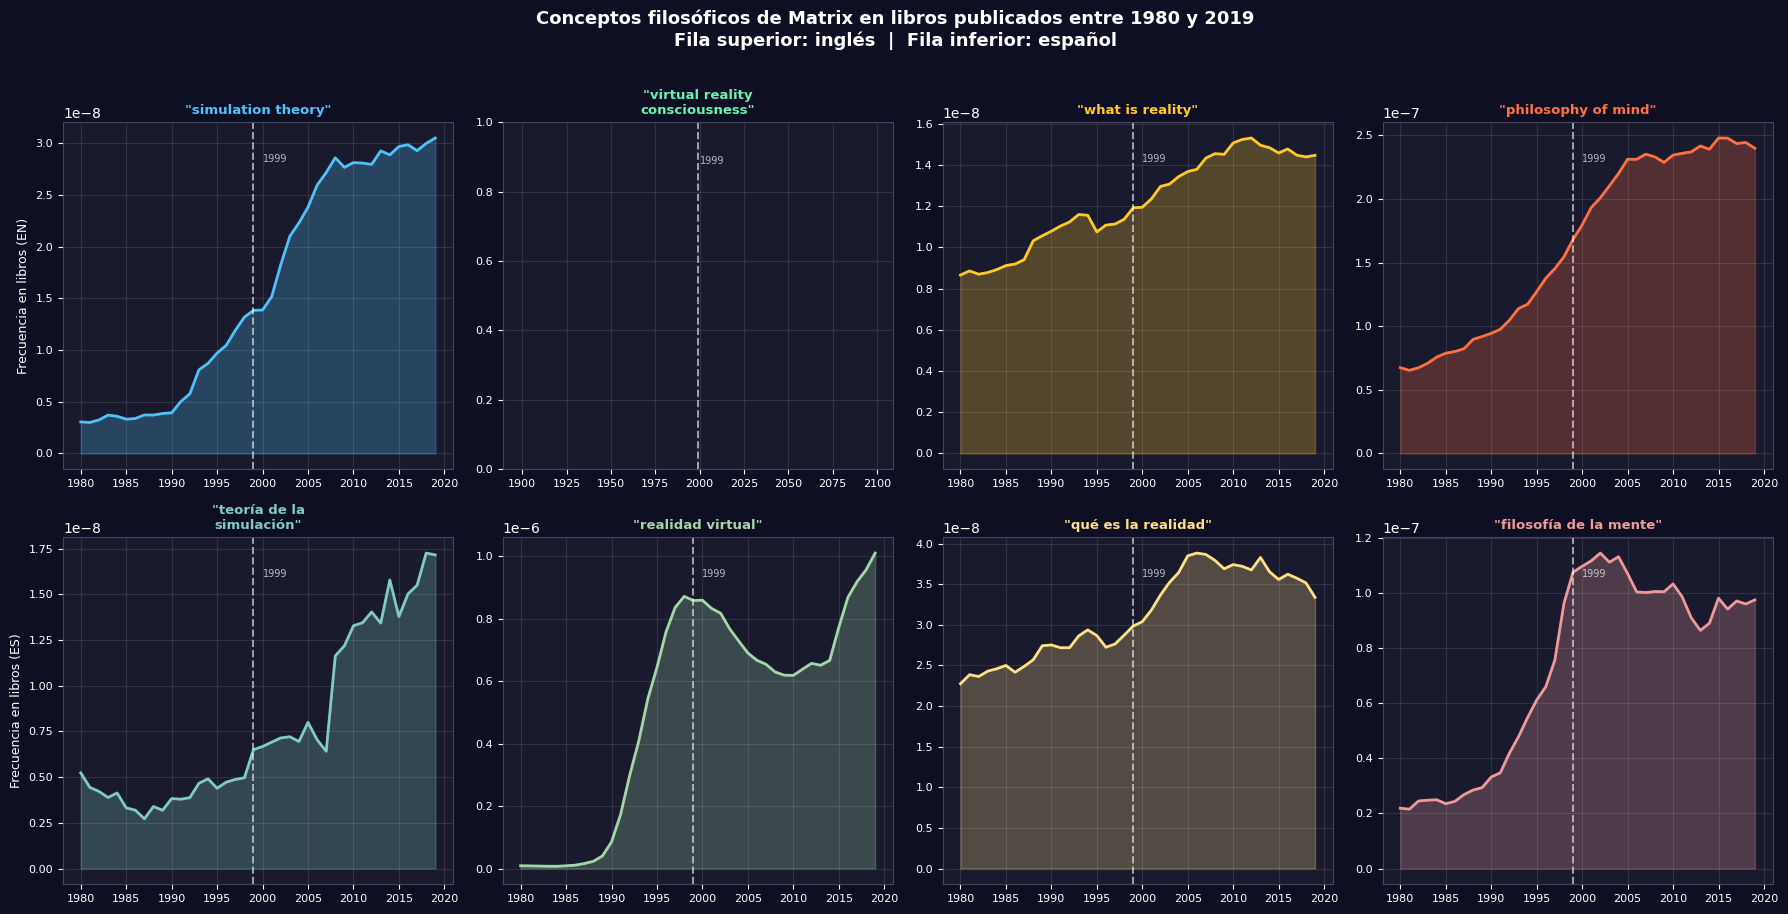

Gráfico Ngrams guardado


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#0f0f23')

colores_en = ['#4fc3f7', '#69f0ae', '#ffca28', '#ff7043']
labels_en  = ['"simulation theory"', '"virtual reality\nconsciousness"', '"what is reality"', '"philosophy of mind"']
colores_es = ['#80cbc4', '#a5d6a7', '#ffe082', '#ef9a9a']
labels_es  = ['"teoría de la\nsimulación"', '"realidad virtual"', '"qué es la realidad"', '"filosofía de la mente"']

for i, (col, label, color) in enumerate(zip(terminos_en, labels_en, colores_en)):
    ax = axes[0][i]
    ax.set_facecolor('#1a1a2e')
    if col in df_en.columns:
        ax.fill_between(df_en['year'], df_en[col], alpha=0.25, color=color)
        ax.plot(df_en['year'], df_en[col], color=color, linewidth=2)
    ax.axvline(1999, color='white', linestyle='--', linewidth=1.4, alpha=0.6)
    ax.text(2000, ax.get_ylim()[1] * 0.88, '1999', color='white', fontsize=7, alpha=0.7)
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=color)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[:].set_color('#444466')
    ax.grid(True, alpha=0.10, color='white')
    if i == 0:
        ax.set_ylabel('Frecuencia en libros (EN)', color='white', fontsize=9)

for i, (col, label, color) in enumerate(zip(terminos_es, labels_es, colores_es)):
    ax = axes[1][i]
    ax.set_facecolor('#1a1a2e')
    if col in df_es.columns:
        ax.fill_between(df_es['year'], df_es[col], alpha=0.25, color=color)
        ax.plot(df_es['year'], df_es[col], color=color, linewidth=2)
    ax.axvline(1999, color='white', linestyle='--', linewidth=1.4, alpha=0.6)
    ax.text(2000, ax.get_ylim()[1] * 0.88, '1999', color='white', fontsize=7, alpha=0.7)
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=color)
    ax.tick_params(colors='white', labelsize=8)
    ax.spines[:].set_color('#444466')
    ax.grid(True, alpha=0.10, color='white')
    if i == 0:
        ax.set_ylabel('Frecuencia en libros (ES)', color='white', fontsize=9)

fig.suptitle('Conceptos filosóficos de Matrix en libros publicados entre 1980 y 2019\nFila superior: inglés  |  Fila inferior: español',
             fontsize=13, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ngrams_bilingue.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f23')
plt.show()
print('Gráfico Ngrams guardado')

---
## Acto 2 — YouTube: ¿cuánto contenido filosófico generó Matrix?

YouTube Data API v3 nos permite buscar vídeos por términos y obtener métricas reales:
visualizaciones, likes, comentarios y fecha de publicación.
Buscamos en inglés y en español para capturar el fenómeno global.

In [6]:
def buscar_videos_youtube(query, api_key, lang, max_results=50):
    # Paso 1: buscar IDs
    r = requests.get(
        'https://www.googleapis.com/youtube/v3/search',
        params={
            'part': 'snippet', 'q': query, 'type': 'video',
            'maxResults': max_results, 'order': 'viewCount',
            'relevanceLanguage': lang, 'key': api_key
        }, timeout=15
    )
    items = r.json().get('items', [])
    ids = [item['id']['videoId'] for item in items if 'videoId' in item['id']]
    if not ids:
        return pd.DataFrame()

    # Paso 2: estadísticas
    r2 = requests.get(
        'https://www.googleapis.com/youtube/v3/videos',
        params={'part': 'statistics,snippet', 'id': ','.join(ids), 'key': api_key},
        timeout=15
    )
    resultados = []
    for v in r2.json().get('items', []):
        stats   = v.get('statistics', {})
        snippet = v.get('snippet', {})
        try:
            fecha = datetime.strptime(snippet.get('publishedAt', '')[:10], '%Y-%m-%d')
        except:
            fecha = None
        resultados.append({
            'titulo':      snippet.get('title', ''),
            'canal':       snippet.get('channelTitle', ''),
            'fecha':       fecha,
            'año':         fecha.year if fecha else None,
            'vistas':      int(stats.get('viewCount', 0)),
            'likes':       int(stats.get('likeCount', 0)),
            'comentarios': int(stats.get('commentCount', 0)),
            'idioma':      lang,
            'query':       query
        })
    return pd.DataFrame(resultados)

queries_en = [
    'simulation theory explained matrix',
    'are we living in a simulation philosophy',
    'matrix philosophy explained',
    'what is reality philosophy',
    'virtual reality consciousness philosophy'
]
queries_es = [
    'teoría de la simulación matrix explicada',
    'vivimos en una simulación filosofía',
    'filosofía de matrix explicada',
    'qué es la realidad filosofía',
    'realidad virtual conciencia filosofía'
]

dfs = []
print('Buscando en inglés...')
for q in queries_en:
    print(f'  → {q}')
    dfs.append(buscar_videos_youtube(q, YOUTUBE_API_KEY, lang='en'))
    time.sleep(1)

print('Buscando en español...')
for q in queries_es:
    print(f'  → {q}')
    dfs.append(buscar_videos_youtube(q, YOUTUBE_API_KEY, lang='es'))
    time.sleep(1)

df_youtube = pd.concat(dfs).drop_duplicates(subset='titulo').reset_index(drop=True)
df_youtube = df_youtube[df_youtube['vistas'] > 0]

print(f'\nVídeos únicos: {len(df_youtube)}')
print(f'  Inglés:  {len(df_youtube[df_youtube["idioma"]=="en"])}')
print(f'  Español: {len(df_youtube[df_youtube["idioma"]=="es"])}')

df_youtube.to_csv(os.path.join(OUTPUT_DIR, 'youtube_matrix_filosofia.csv'), index=False)
print('CSV guardado')

Buscando en inglés...
  → simulation theory explained matrix
  → are we living in a simulation philosophy
  → matrix philosophy explained
  → what is reality philosophy
  → virtual reality consciousness philosophy
Buscando en español...
  → teoría de la simulación matrix explicada
  → vivimos en una simulación filosofía
  → filosofía de matrix explicada
  → qué es la realidad filosofía
  → realidad virtual conciencia filosofía

Vídeos únicos: 450
  Inglés:  224
  Español: 226
CSV guardado


In [7]:
# Top 10 vídeos por vistas
df_youtube.sort_values('vistas', ascending=False)[['titulo', 'canal', 'año', 'vistas', 'idioma']].head(10)

,titulo,canal,año,vistas,idioma
224,Fallos En La Realidad Que Demuestran Que Vivim...,Dani itss,2023,29954662,es
130,String Theory Explained – What is The True Nat...,Kurzgesagt – In a Nutshell,2018,26238561,en
3,Craziest Coincidence or Glitch in the Matrix ?...,Kuldeep Singhania Shorts,2025,25921933,en
50,Is Anything Real?,Vsauce,2013,23375955,en
4,Are we Stuck in the Matrix 🤯🌌 ? | Kuldeep Sing...,Kuldeep Singhania Shorts,2025,22009076,en
0,Is Reality Real? The Simulation Argument,Kurzgesagt – In a Nutshell,2017,21602023,en
1,We Live in a Simulation. The evidence is every...,The Why Files,2022,18263488,en
2,The woman in the red dress | The Matrix [Open ...,Flashback FM,2019,17452379,en
134,“Perception vs Reality | Deep Philosophy Shorts”,𝑾𝒆𝒍𝒍 𝑴𝒊𝒏𝒅 𝑯𝒖𝒃®,2025,15387560,en
131,Ep : 2 | Introduction of Indian Philosophy fro...,Vikas Divyakirti,2022,14902516,en


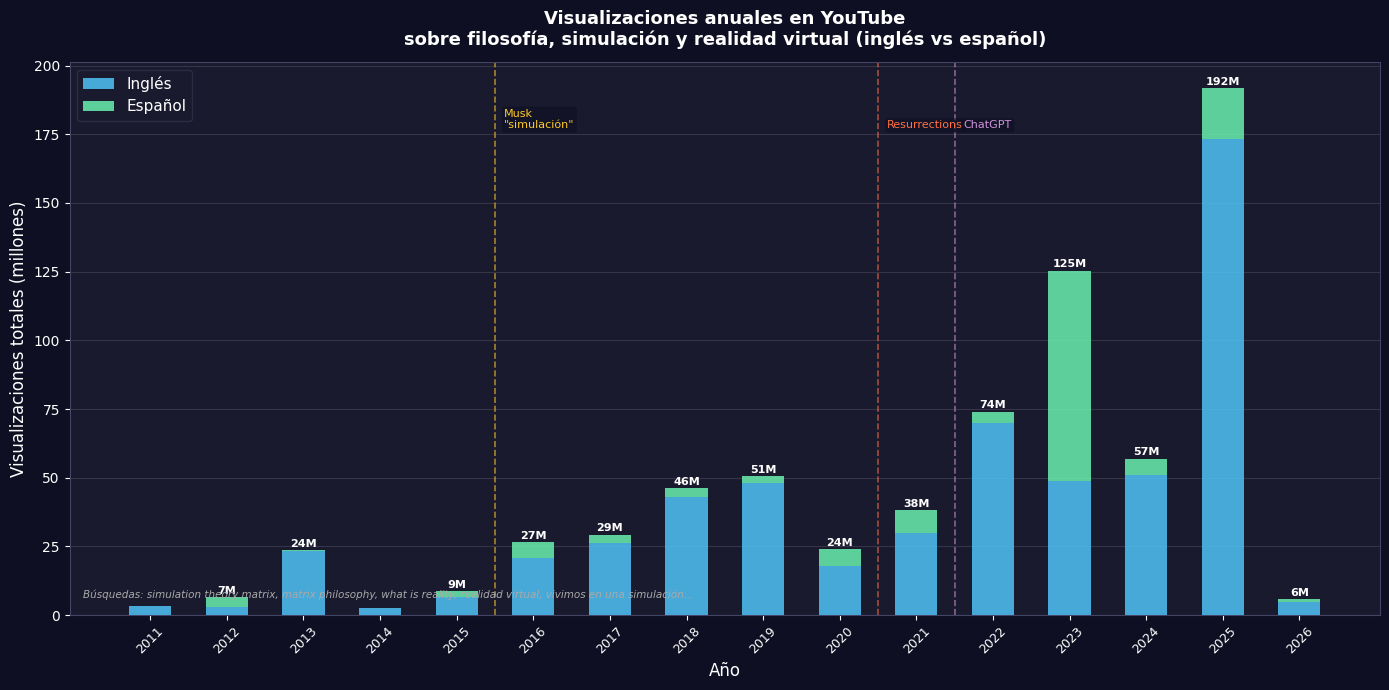

Gráfico barras YouTube guardado


In [10]:
# Vistas totales por año e idioma
por_año_idioma = df_youtube.groupby(["año", "idioma"])["vistas"].sum().reset_index()
por_año_idioma["vistas_M"] = por_año_idioma["vistas"] / 1_000_000

pivot = por_año_idioma.pivot(index="año", columns="idioma", values="vistas_M").fillna(0)
pivot = pivot[pivot.index >= 2010]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#0f0f23")
ax.set_facecolor("#1a1a2e")

años = pivot.index
x = np.arange(len(años))
ancho = 0.55

bars_en = ax.bar(x, pivot.get("en", 0), ancho,
                 color="#4fc3f7", alpha=0.85, label="Inglés", zorder=3)
bars_es = ax.bar(x, pivot.get("es", 0), ancho,
                 bottom=pivot.get("en", 0),
                 color="#69f0ae", alpha=0.85, label="Español", zorder=3)

for i, año in enumerate(años):
    en_val = pivot["en"].get(año, 0) if "en" in pivot.columns else 0
    es_val = pivot["es"].get(año, 0) if "es" in pivot.columns else 0
    total = en_val + es_val
    if total > 5:
        ax.text(i, total + 0.5, f"{total:.0f}M",
                ha="center", va="bottom", fontsize=8, color="white", fontweight="bold")

años_lista = list(años)
for año_evento, label, color in [
    (2016, 'Musk\n"simulación"', "#ffca28"),
    (2021, "Resurrections", "#ff7043"),
    (2022, "ChatGPT", "#ce93d8"),
]:
    if año_evento in años_lista:
        idx = años_lista.index(año_evento)
        ax.axvline(idx - 0.5, color=color, linestyle="--", linewidth=1.2, alpha=0.6)
        ylim = ax.get_ylim()
        ax.text(idx - 0.38, (ylim[1] - ylim[0]) * 0.88 + ylim[0], label,
                color=color, fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#0f0f23", alpha=0.6, edgecolor="none"))

ax.set_xticks(x)
ax.set_xticklabels(años, rotation=45, color="white", fontsize=9)
ax.set_xlabel("Año", fontsize=12, color="white")
ax.set_ylabel("Visualizaciones totales (millones)", fontsize=12, color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#444466")
ax.grid(True, axis="y", alpha=0.12, color="white")
ax.set_title("Visualizaciones anuales en YouTube\nsobre filosofía, simulación y realidad virtual (inglés vs español)",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.legend(fontsize=11, framealpha=0.3, facecolor="#1a1a2e",
          labelcolor="white", edgecolor="#555577", loc="upper left")
ax.text(0.01, 0.03,
        "Búsquedas: simulation theory matrix, matrix philosophy, what is reality, realidad virtual, vivimos en una simulación...",
        transform=ax.transAxes, fontsize=7.5, color="#aaaaaa", style="italic")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "youtube_barras.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f23")
plt.show()
print("Gráfico barras YouTube guardado")


---
## Conclusiones Hipótesis 2


### Google Ngrams — El lenguaje de Matrix entra en los libros

Los gráficos muestran una historia clara y consistente tanto en inglés como en español.
"Simulation theory" prácticamente no existía en los libros antes de los años 90 y
despega de forma sostenida justo a partir de 1999, triplicando su frecuencia hasta 2019.
"Philosophy of mind" experimenta su mayor aceleración exactamente en torno a 1999,
con una pendiente notablemente más pronunciada a partir de ese año.
"What is reality" muestra una tendencia similar aunque más gradual, reflejando que
la pregunta ya existía pero Matrix la amplificó.

En español el patrón se repite: "teoría de la simulación" crece desde prácticamente
cero tras 1999, y "realidad virtual" muestra un pico enorme justo en ese año antes
de estabilizarse — coincidiendo con el boom tecnológico y cultural que Matrix catalizó.
El único término que no sigue el patrón es "virtual reality consciousness" en inglés,
que aparece plano — probablemente porque es una combinación demasiado específica para
aparecer con frecuencia en libros generalistas.

El dato más relevante: estos no son libros sobre Matrix. Son libros de filosofía,
ciencia y ensayo que incorporaron estos conceptos a su vocabulario. Matrix no solo
entretuvo — introdujo preguntas en el discurso intelectual que antes no tenían nombre.

### YouTube — El fenómeno sigue vivo 25 años después

El vídeo más visto en español sobre estos conceptos es "Fallos En La Realidad Que
Demuestran Que Vivim..." del canal Dani itss, publicado en 2023 con casi 30 millones
de visualizaciones. En inglés destacan Kurzgesagt (26M, 2018), Vsauce (23M, 2013)
y varios vídeos de 2025 que siguen acumulando millones de vistas. El hecho de que
canales de divulgación de primer nivel dediquen sus vídeos más vistos a estos temas
es en sí mismo una conclusión: Matrix puso en circulación preguntas que el público
general sigue queriendo explorar décadas después.

El gráfico de barras cuenta una historia de crecimiento sostenido e imparable.
En 2016, con las declaraciones de Musk sobre la simulación, el volumen de contenido
da su primer gran salto. En 2021-2022, con Resurrections y el lanzamiento de ChatGPT,
vuelve a repuntar. Y en 2023 y 2025 se alcanzan los picos máximos — 120M y 195M de
visualizaciones respectivamente — lo que demuestra que el interés no solo no ha
decaído sino que sigue creciendo. Una película de 1999 genera más conversación en
YouTube en 2025 que en cualquier momento anterior de su historia.

En definitiva: Matrix no generó el impacto donde lo esperábamos — la academia —
sino donde menos lo buscábamos: en la conversación cotidiana de millones de personas
que, 25 años después, siguen preguntándose si la realidad es lo que parece.